In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mingangolo/covid-19-world-data/covid_19_data.csv


In [2]:
# Cell 1 — imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#fafafa'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
# Cell 2 - find the files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mingangolo/covid-19-world-data/covid_19_data.csv


In [4]:
# Cell 3 — load the data
df = pd.read_csv('/kaggle/input/datasets/mingangolo/covid-19-world-data/covid_19_data.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (306429, 8)

Columns: ['SNo', 'ObservationDate', 'Province/State', 'Country/Region', 'Last Update', 'Confirmed', 'Deaths', 'Recovered']


,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [5]:
# Cell 4 - understand what's inside
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== SAMPLE VALUES ===")
for col in df.columns:
    print(f"{col}: {df[col].unique()[:3]}")

=== DATA TYPES ===
SNo                  int64
ObservationDate     object
Province/State      object
Country/Region      object
Last Update         object
Confirmed          float64
Deaths             float64
Recovered          float64
dtype: object

=== NULL VALUES ===
SNo                    0
ObservationDate        0
Province/State     78103
Country/Region         0
Last Update            0
Confirmed              0
Deaths                 0
Recovered              0
dtype: int64

=== SAMPLE VALUES ===
SNo: [1 2 3]
ObservationDate: ['01/22/2020' '01/23/2020' '01/24/2020']
Province/State: ['Anhui' 'Beijing' 'Chongqing']
Country/Region: ['Mainland China' 'Hong Kong' 'Macau']
Last Update: ['1/22/2020 17:00' '1/23/20 17:00' '1/24/20 17:00']
Confirmed: [ 1. 14.  6.]
Deaths: [ 0. 17. 24.]
Recovered: [ 0. 28.  2.]


In [6]:
# Cell 5 — clean and prepare
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'], format='mixed', dayfirst=False)

# Fill missing Province/State
df['Province/State'] = df['Province/State'].fillna('Unknown')

# Standardize country names
df['Country/Region'] = df['Country/Region'].replace({
    'Mainland China': 'China',
    'UK': 'United Kingdom',
    'US': 'USA'
})

# Drop duplicates
df = df.drop_duplicates()

# Add time columns
df['Year']  = df['ObservationDate'].dt.year
df['Month'] = df['ObservationDate'].dt.month
df['YearMonth'] = df['ObservationDate'].dt.to_period('M')

print("Cleaned shape:", df.shape)
print("Date range:", df['ObservationDate'].min().date(), "→", df['ObservationDate'].max().date())
print("Countries:", df['Country/Region'].nunique())

Cleaned shape: (306429, 11)
Date range: 2020-01-22 → 2021-05-29
Countries: 228


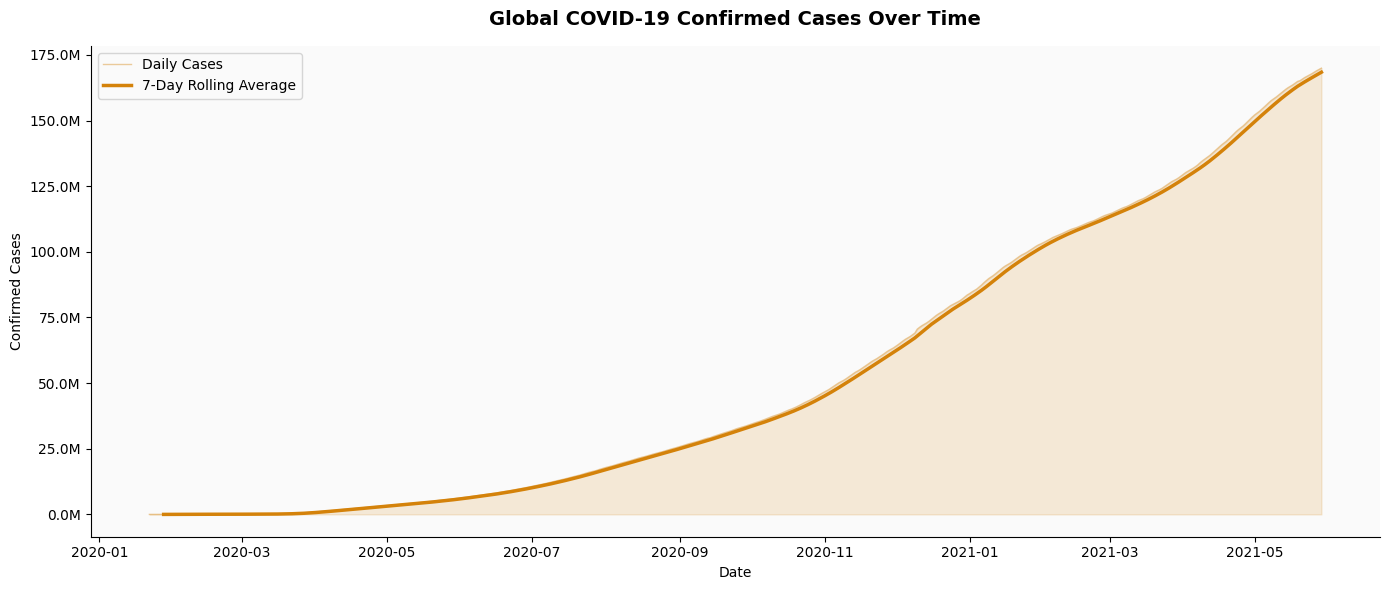

Saved: chart1_global_trend.png ✓


In [7]:
# Cell 6 — CHART 1: Global daily confirmed cases trend
global_daily = df.groupby('ObservationDate')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
global_daily = global_daily.sort_values('ObservationDate')

# 7-day rolling average
global_daily['Confirmed_7day'] = global_daily['Confirmed'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(global_daily['ObservationDate'], global_daily['Confirmed'],
                alpha=0.15, color='#d4820a')
ax.plot(global_daily['ObservationDate'], global_daily['Confirmed'],
        color='#d4820a', linewidth=1, alpha=0.4, label='Daily Cases')
ax.plot(global_daily['ObservationDate'], global_daily['Confirmed_7day'],
        color='#d4820a', linewidth=2.5, label='7-Day Rolling Average')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Global COVID-19 Confirmed Cases Over Time', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Confirmed Cases', fontsize=10)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart1_global_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_global_trend.png ✓")

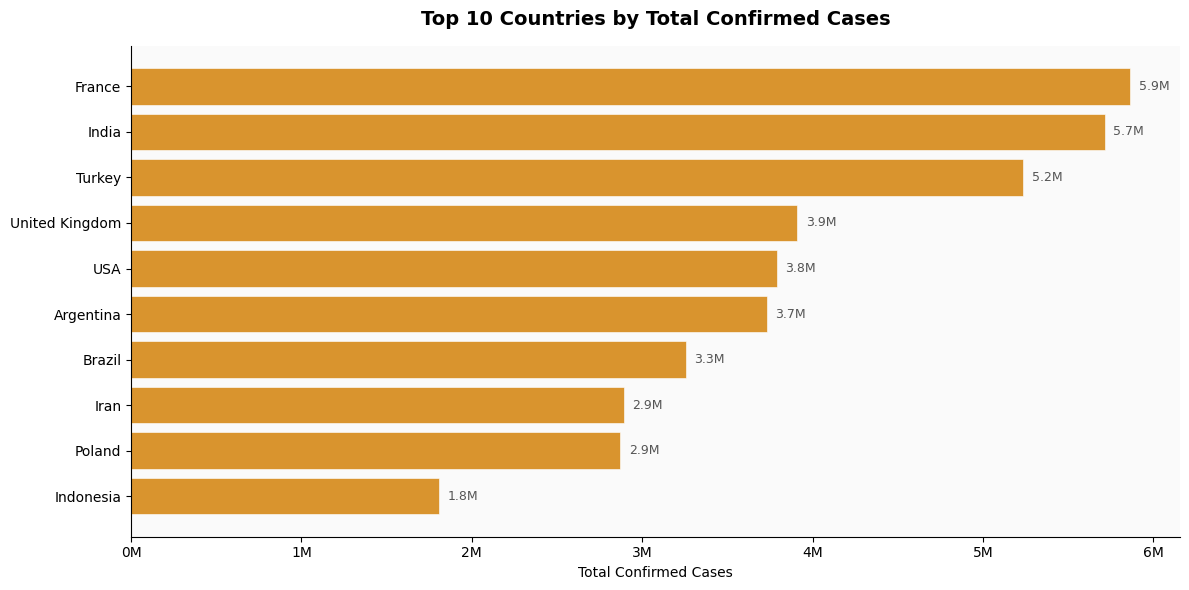

Saved: chart2_top_countries.png ✓


In [8]:
# Cell 7 — CHART 2: Top 10 countries by total confirmed cases
latest = df.groupby('Country/Region')[['Confirmed', 'Deaths', 'Recovered']].max().reset_index()
top10 = latest.nlargest(10, 'Confirmed')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['Country/Region'], top10['Confirmed'],
               color='#d4820a', alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top10['Confirmed']):
    ax.text(val + 50000, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=9, color='#555')

ax.set_title('Top 10 Countries by Total Confirmed Cases', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Confirmed Cases', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('chart2_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart2_top_countries.png ✓")

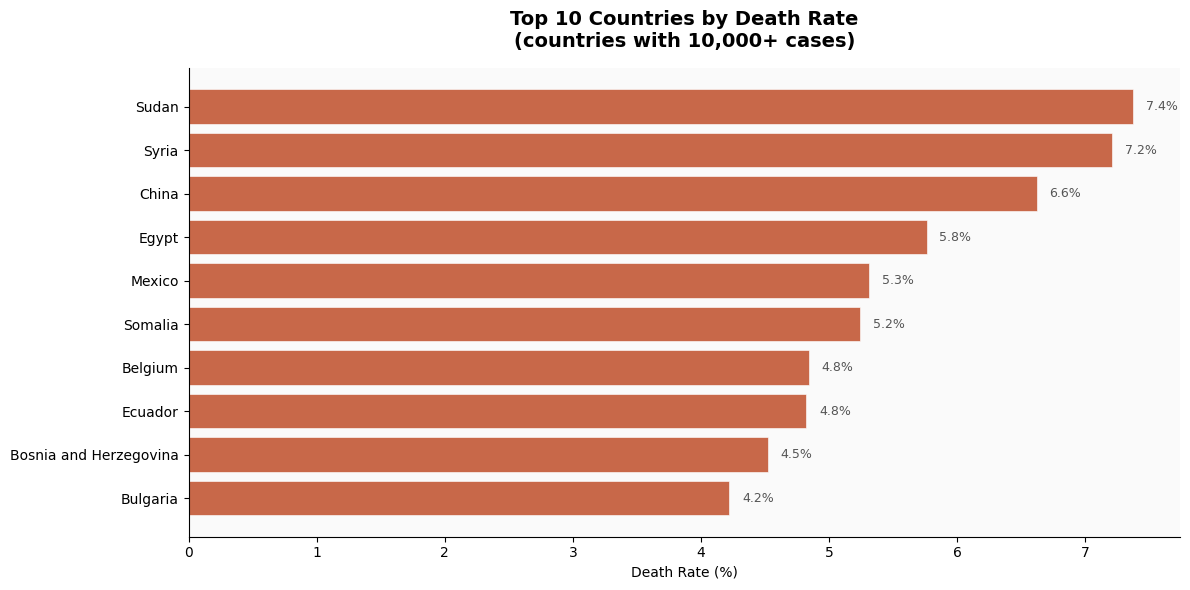

Saved: chart3_death_rate.png ✓


In [9]:
# Cell 8 — CHART 3: Death rate by country (top 10 highest)
latest['Death_Rate'] = (latest['Deaths'] / latest['Confirmed'] * 100).round(2)
top_death_rate = latest[latest['Confirmed'] > 10000].nlargest(10, 'Death_Rate')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_death_rate['Country/Region'], top_death_rate['Death_Rate'],
               color='#c04e2a', alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top_death_rate['Death_Rate']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color='#555')

ax.set_title('Top 10 Countries by Death Rate\n(countries with 10,000+ cases)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Death Rate (%)', fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('chart3_death_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart3_death_rate.png ✓")

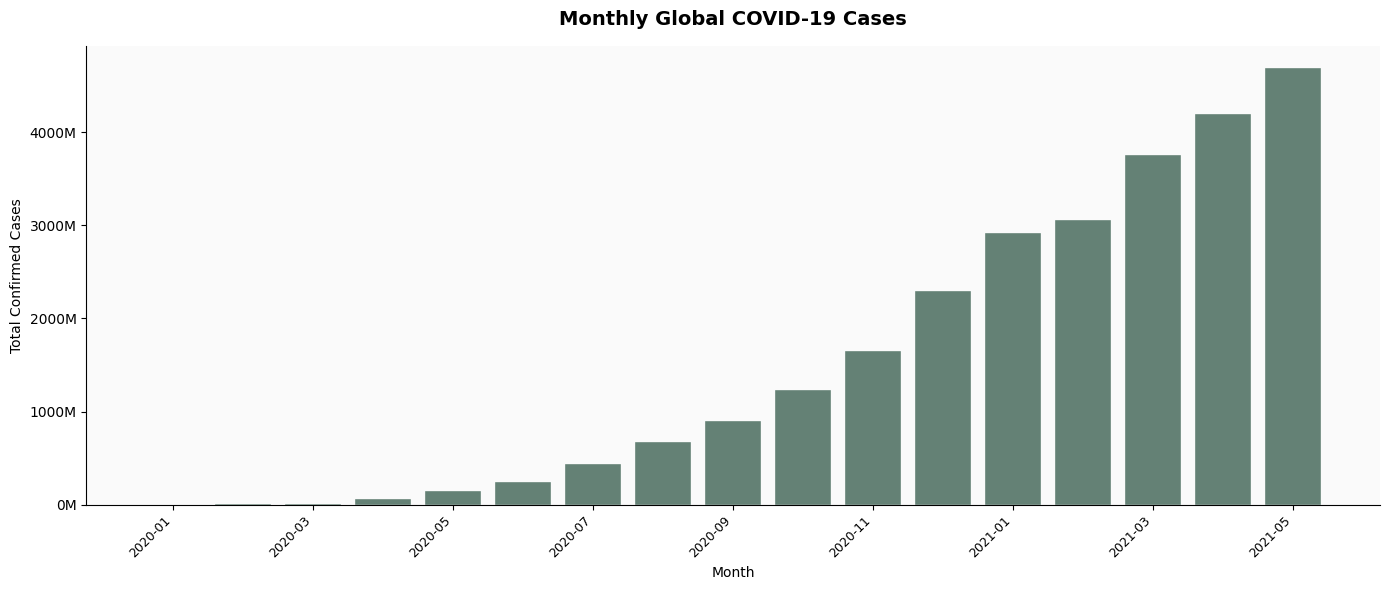

Saved: chart4_monthly_cases.png ✓


In [10]:
# Cell 9 — CHART 4: Monthly global cases trend
monthly = df.groupby('YearMonth')['Confirmed'].sum().reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(monthly['YearMonth_str'], monthly['Confirmed'],
       color='#4a6c5e', alpha=0.85, edgecolor='white', linewidth=0.3)

ax.set_xticks(range(0, len(monthly), 2))
ax.set_xticklabels(monthly['YearMonth_str'].iloc[::2], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_title('Monthly Global COVID-19 Cases', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Total Confirmed Cases', fontsize=10)

plt.tight_layout()
plt.savefig('chart4_monthly_cases.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart4_monthly_cases.png ✓")

In [11]:
# Cell 10 — KEY NUMBERS
total_confirmed = latest['Confirmed'].sum()
total_deaths    = latest['Deaths'].sum()
total_recovered = latest['Recovered'].sum()
global_death_rate = (total_deaths / total_confirmed * 100)

top_country     = latest.nlargest(1, 'Confirmed').iloc[0]
highest_dr      = latest[latest['Confirmed'] > 10000].nlargest(1, 'Death_Rate').iloc[0]
total_countries = latest['Country/Region'].nunique()

print("=" * 50)
print(f"  Total Confirmed:   {total_confirmed:,.0f}")
print(f"  Total Deaths:      {total_deaths:,.0f}")
print(f"  Total Recovered:   {total_recovered:,.0f}")
print(f"  Global Death Rate: {global_death_rate:.2f}%")
print("=" * 50)
print(f"  Most affected:     {top_country['Country/Region']} ({top_country['Confirmed']/1e6:.1f}M cases)")
print(f"  Highest death rate:{highest_dr['Country/Region']} ({highest_dr['Death_Rate']:.1f}%)")
print(f"  Countries affected:{total_countries}")
print("=" * 50)

  Total Confirmed:   78,843,232
  Total Deaths:      1,672,981
  Total Recovered:   65,604,778
  Global Death Rate: 2.12%
  Most affected:     France (5.9M cases)
  Highest death rate:Sudan (7.4%)
  Countries affected:228


In [12]:
# Cell 11 - save all files
import os

# Save clean data
df.to_csv('covid_clean.csv', index=False)
latest.to_csv('covid_by_country.csv', index=False)

print("All files saved!")
print("\nChart files:")
for f in os.listdir('.'):
    if f.startswith('chart'):
        print(f" - {f}")

All files saved!

Chart files:
 - chart2_top_countries.png
 - chart1_global_trend.png
 - chart4_monthly_cases.png
 - chart3_death_rate.png
